<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>


# Máquinas Vetores de Suporte (*Support Vector Machines - SVM*)

In [ ]:
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.svm import SVC, SVR
from sklearn import datasets, svm
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_iris, make_classification, make_moons, fetch_california_housing

## 1. Classificação (Linear e Não Linear)

A classificação SVM busca encontrar o hiperplano ótimo que maximiza a margem entre as classes. A utilização de funções de Kernel permite a separação de dados não linearmente separáveis projetando-os em dimensões superiores.

**Parâmetros interativos:**
* **Kernel:** Função matemática utilizada para o mapeamento (Linear, RBF, Polinomial, Sigmoid).

* **C (Regularização):** Controla o rigor do ajuste. Valores baixos priorizam uma margem larga (maior generalização). Valores altos penalizam rigorosamente erros de classificação (risco de *overfitting*).

* **Gamma:** Define o raio de influência das amostras no kernel RBF.

* **Grau:** Expoente aplicado exclusivamente ao kernel Polinomial.

**Conjunto de Dados:** *Iris Dataset* (dados reais de medidas botânicas). Serão utilizadas apenas as características "Comprimento da Sépala" e "Largura da Sépala" para permitir a visualização em 2D.

In [ ]:
# ==========================================
# PREPARAÇÃO DOS DADOS DE CLASSIFICAÇÃO
# ==========================================
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data[:, :2])
y_iris = iris.target

X_lin, y_lin = make_classification(n_features=2, n_redundant=0, n_informative=2,
                                   random_state=1, n_clusters_per_class=1, class_sep=1.2)

X_nonlin, y_nonlin = make_moons(n_samples=150, noise=0.15, random_state=42)

In [ ]:
# ==========================================
# FUNÇÃO DE PLOTAGEM INTERATIVA
# ==========================================
def plot_svm_classification(dataset, kernel, C_log, gamma_log, degree):
    if dataset == 'Iris (Reais)':
        X, y = X_iris, y_iris
    elif dataset == 'Linear (Sintético)':
        X, y = X_lin, y_lin
    else:
        X, y = X_nonlin, y_nonlin

    C = 10 ** C_log
    gamma = 10 ** gamma_log if gamma_log != 'auto' else 'scale'

    clf = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)
    clf.fit(X, y)

    fig, ax = plt.subplots(figsize=(10, 6))

    DecisionBoundaryDisplay.from_estimator(
        clf, X, response_method="predict",
        cmap=plt.cm.coolwarm, alpha=0.4, ax=ax,
        grid_resolution=50
    )

    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=200, facecolors="none", edgecolors="k", linewidths=1.5, label="Vetores de Suporte")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors="k")

    # ---------------------------------------------------------
    # AVISO VISUAL SE O GRAU FOR INÚTIL NO KERNEL ATUAL
    # ---------------------------------------------------------
    if kernel != 'poly':
        ax.text(0.5, -0.15, "* AVISO: O parâmetro 'Grau' só tem efeito quando o Kernel é 'poly'.",
                transform=ax.transAxes, ha='center', va='center', color='white',
                bbox=dict(facecolor='red', alpha=0.8, edgecolor='none', pad=5), fontweight='bold')

    ax.legend(loc="upper right")
    ax.set_title(f"Classificação SVM | Dataset: {dataset} | Kernel: {kernel} | C: {C:.2f}")
    plt.show()

# ==========================================
# INTERFACE DE CONTROLES
# ==========================================
widgets.interact(
    plot_svm_classification,
    dataset=widgets.Dropdown(options=['Iris (Reais)', 'Linear (Sintético)', 'Moons (Sintético)'], value='Iris (Reais)', description='Dataset:'),
    kernel=widgets.Dropdown(options=['linear', 'rbf', 'poly', 'sigmoid'], value='rbf', description='Kernel:'),
    C_log=widgets.FloatSlider(value=0.0, min=-2.0, max=3.0, step=0.5, description='Log10(C):', continuous_update=False),
    gamma_log=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.5, description='Log10(Gamma):', continuous_update=False),
    degree=widgets.IntSlider(value=3, min=2, max=5, description='Grau (Poly):', continuous_update=False)
);

interactive(children=(Dropdown(description='Dataset:', options=('Iris (Reais)', 'Linear (Sintético)', 'Moons (…

## 2. Regressão (Linear e Não Linear)

Na Regressão com SVM (SVR), o objetivo inverte-se em relação à classificação: busca-se ajustar o maior número possível de instâncias *dentro* da margem (o tubo), minimizando os erros que ocorrem fora dela.

**Parâmetros interativos:**

* **Epsilon ($\epsilon$):** Define a largura do tubo de insensibilidade. Erros dentro deste tubo não são penalizados na função de custo.

* **C e Kernel:** Possuem a mesma função de controle de complexidade e mapeamento descrita na seção de classificação.

**Conjunto de Dados:** *California Housing* (dados imobiliários reais). Projeta-se a "Renda Mediana" ($X$) contra o "Valor Mediano da Casa" ($y$). Utilizou-se uma amostragem de 150 pontos para manter a renderização gráfica rápida e interativa.

In [ ]:
# ==========================================
# PREPARAÇÃO DOS DADOS
# ==========================================
california = fetch_california_housing()
X_reg_full = california.data[:, 0].reshape(-1, 1)
y_reg_full = california.target

np.random.seed(42)
indices = np.random.choice(len(X_reg_full), 150, replace=False)
X_reg_sample = X_reg_full[indices]
y_reg_sample = y_reg_full[indices]

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_sample)

sort_idx = np.argsort(X_reg_scaled[:, 0])
X_reg_scaled = X_reg_scaled[sort_idx]
y_reg_sample = y_reg_sample[sort_idx]

In [ ]:
# ==========================================
# FUNÇÃO DE PLOTAGEM INTERATIVA
# ==========================================
def plot_svm_regression(kernel, C_log, epsilon, gamma_log, degree):
    C = 10 ** C_log
    gamma = 10 ** gamma_log if gamma_log != 'auto' else 'scale'

    svr = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma, degree=degree)
    svr.fit(X_reg_scaled, y_reg_sample)

    X_plot = np.linspace(X_reg_scaled.min(), X_reg_scaled.max(), 100).reshape(-1, 1)
    y_pred = svr.predict(X_plot)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(X_reg_scaled, y_reg_sample, color="black", alpha=0.6, label="Amostras (Real)")
    ax.plot(X_plot, y_pred, color="red", lw=2, label="Regressão (SVR)")
    ax.plot(X_plot, y_pred + epsilon, color="red", linestyle="--", alpha=0.4, label="Tubo (+ε)")
    ax.plot(X_plot, y_pred - epsilon, color="red", linestyle="--", alpha=0.4, label="Tubo (-ε)")

    ax.scatter(X_reg_scaled[svr.support_], y_reg_sample[svr.support_],
               facecolor="none", edgecolor="blue", s=150, linewidths=1.5, label="Vetores de Suporte")

    # ---------------------------------------------------------
    # AVISO VISUAL SE O GRAU FOR INÚTIL NO KERNEL ATUAL
    # ---------------------------------------------------------
    if kernel != 'poly':
        ax.text(0.5, -0.20, "* AVISO: O parâmetro 'Grau' só tem efeito quando o Kernel é 'poly'.",
                transform=ax.transAxes, ha='center', va='center', color='white',
                bbox=dict(facecolor='red', alpha=0.8, edgecolor='none', pad=5), fontweight='bold')

    ax.set_xlabel("Renda Mediana (Padronizada)")
    ax.set_ylabel("Valor Mediano da Casa ($100k)")
    ax.set_title(f"Regressão SVR | Kernel: {kernel} | C: {C:.2f} | ε: {epsilon}")
    ax.legend(loc="upper left")
    plt.show()

# ==========================================
# INTERFACE DE CONTROLES
# ==========================================
widgets.interact(
    plot_svm_regression,
    kernel=widgets.Dropdown(options=['linear', 'rbf', 'poly', 'sigmoid'], value='rbf', description='Kernel:'),
    C_log=widgets.FloatSlider(value=1.0, min=-1.0, max=3.0, step=0.5, description='Log10(C):', continuous_update=False),
    epsilon=widgets.FloatSlider(value=0.5, min=0.0, max=2.0, step=0.1, description='Epsilon (ε):', continuous_update=False),
    gamma_log=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.5, description='Log10(Gamma):', continuous_update=False),
    degree=widgets.IntSlider(value=3, min=2, max=5, description='Grau (Poly):', continuous_update=False)
);

interactive(children=(Dropdown(description='Kernel:', index=1, options=('linear', 'rbf', 'poly', 'sigmoid'), v…

## 3. Comparação Visual Estática (Diferentes Modelos e Kernels)

Enquanto as seções anteriores permitiram explorar os hiperparâmetros dinamicamente, este painel serve como um resumo estático. Ele compara como diferentes implementações de SVM constroem suas fronteiras de decisão no mesmo conjunto de dados (Iris).

* **SVC com kernel linear vs. LinearSVC:** Embora ambos tracem hiperplanos retos, eles otimizam funções de custo ligeiramente diferentes (o `LinearSVC` minimiza a perda de articulação ao quadrado e usa a abordagem *One-vs-Rest* para múltiplas classes).

* **RBF vs. Polinomial:** Demonstra a flexibilidade das curvas geradas por mapeamentos não lineares.

In [ ]:
# ==========================================
# PREPARAÇÃO E ESCALONAMENTO DOS DADOS
# ==========================================
iris = datasets.load_iris()
# Pegamos apenas as duas primeiras características
X_bruto = iris.data[:, :2]
y = iris.target

# Padronização (Essencial para convergência do LinearSVC e margens corretas)
scaler = StandardScaler()
X = scaler.fit_transform(X_bruto)

In [ ]:
# ==========================================
# TREINAMENTO DOS MODELOS
# ==========================================
C = 1.0  # Parâmetro de regularização padrão
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000, dual="auto"), # dual="auto" suprime warnings recentes do scikit-learn
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="scale", C=C),
)

# Treina todos os modelos em uma compreensão de lista
models = [clf.fit(X, y) for clf in models]

# Títulos para os subplots
titles = (
    "SVC com kernel linear",
    "LinearSVC (kernel linear)",
    "SVC com kernel RBF",
    "SVC com kernel polinomial (grau 3)",
)

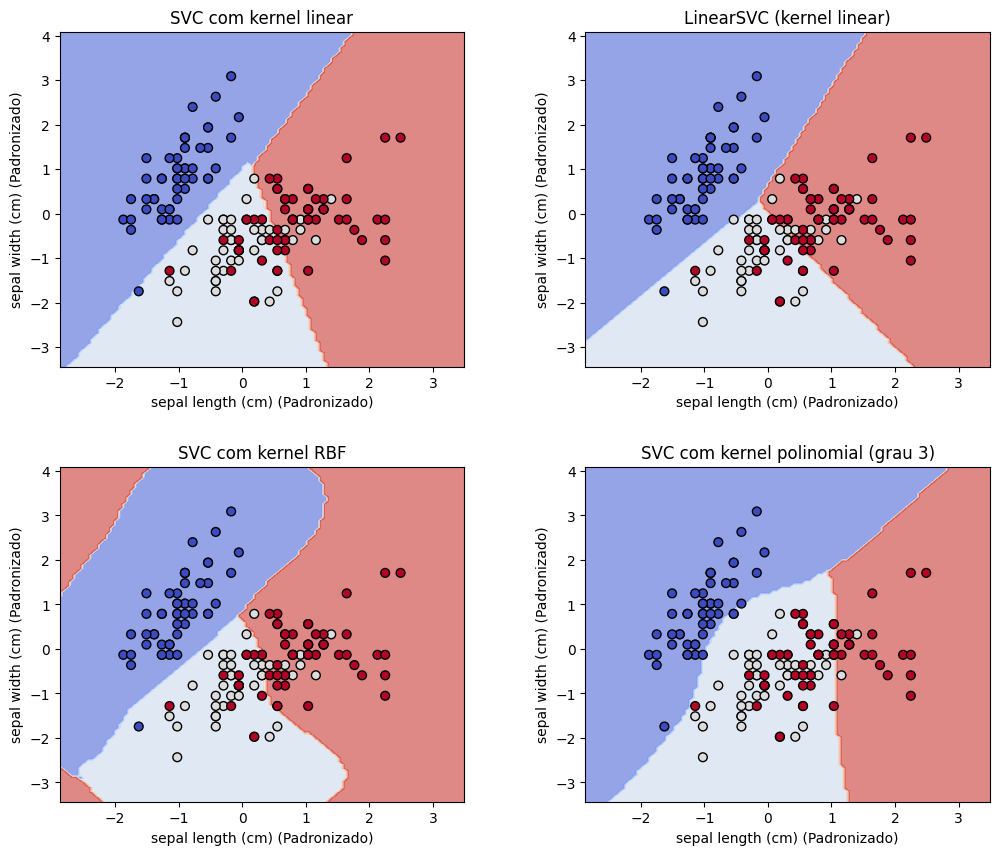

In [ ]:
# ==========================================
# PLOTAGEM DO GRID 2x2
# ==========================================
fig, sub = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.6,
        ax=ax,
        xlabel=f"{iris.feature_names[0]} (Padronizado)",
        ylabel=f"{iris.feature_names[1]} (Padronizado)",
    )
    # Plota as amostras
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=40, edgecolors="k")
    ax.set_title(title)

plt.show()